# Importing Lib's & DataSet

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, Bidirectional, LSTM, Input, Dropout
from tensorflow.keras.layers import Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/eng_-french.csv.zip')
df.head()

,English words/sentences,French words/sentences
0,Hi.,Salut!
1,Run!,Cours !
2,Run!,Courez !
3,Who?,Qui ?
4,Wow!,Ça alors !


# EDA

In [ ]:
df.shape

(175621, 2)

In [ ]:
df.isnull().sum()

,0
English words/sentences,0
French words/sentences,0


In [ ]:
df = df.rename(columns={'English words/sentences':'English','French words/sentences':'French'})
df.head()

,English,French
0,Hi.,Salut!
1,Run!,Cours !
2,Run!,Courez !
3,Who?,Qui ?
4,Wow!,Ça alors !


In [ ]:
def word_count(word):
    return len(word.split())

df['English_word_count'] = df['English'].apply(lambda x : word_count(x))
df['French_word_count'] = df['French'].apply(lambda x : word_count(x))

In [ ]:
print(df['English_word_count'].sum())
print(df['French_word_count'].sum())

1082098
1177832


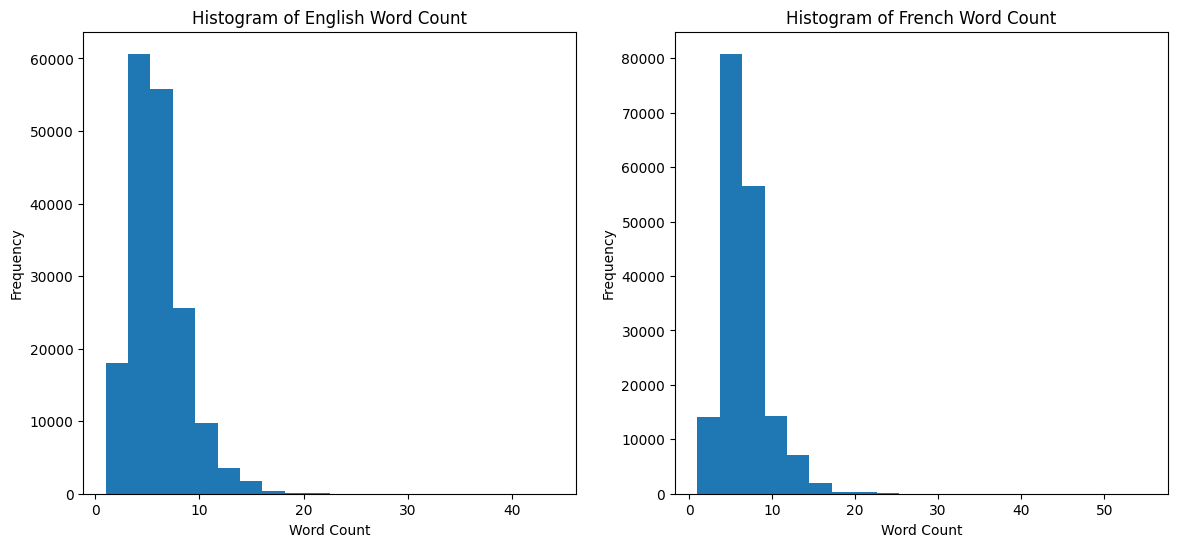

In [ ]:
plt.figure(figsize= (14, 6))

plt.subplot(1, 2, 1)
plt.hist(df['English_word_count'], bins= 20)
plt.title('Histogram of English Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['French_word_count'], bins= 20)
plt.title('Histogram of French Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

# Tokenizing & Padding

In [ ]:
def tokenize(x):
    x_tk = Tokenizer(char_level= False)
    x_tk.fit_on_texts(x)
    return x_tk.texts_to_sequences(x), x_tk

In [ ]:
def padding(x):
    if length is None:
        length = max([len(sent) for sent in x])
    return pad_sequences(x, maxlen= length, padding= 'post')

In [ ]:
# Tokenize English and French sentences
english_sequences, english_tokenizer = tokenize(df['English'])
french_sequences, french_tokenizer = tokenize(df['French'])

# Get the length of sequences
english_sequence_lengths = [len(seq) for seq in english_sequences]
french_sequence_lengths = [len(seq) for seq in french_sequences]

print(f"Maximum English sequence length: {max(english_sequence_lengths)}")
print(f"Maximum French sequence length: {max(french_sequence_lengths)}")

Maximum English sequence length: 44
Maximum French sequence length: 55


# Splitting Data, Tokenizing, Padding

In [ ]:
train_data, test_data = train_test_split(df, test_size= 0.2, random_state= 42)

In [ ]:
train_data = train_data.drop(['English_word_count', 'French_word_count'], axis= 1)
test_data = test_data.drop(['English_word_count', 'French_word_count'], axis= 1)

In [ ]:
# Train & Test 'Seqs & Tokens'
x_train_seq, x_train_tok = tokenize(train_data['English'])
y_train_seq, y_train_tok = tokenize(train_data['French'])

x_test_seq, x_test_tok = tokenize(test_data['English'])
y_test_seq, y_test_tok = tokenize(test_data['French'])

# Train & Test 'Vocab Size'
x_train_vocab = len(x_train_tok.word_index) + 1
y_train_vocab = len(y_train_tok.word_index) + 1

x_test_vocab = len(x_test_tok.word_index) + 1
y_test_vocab = len(y_test_tok.word_index) + 1

# Train & Test 'Padding'
max_french_length = max([len(seq) for seq in y_train_seq])
x_train_seq = pad_sequences(x_train_seq, maxlen=max_french_length, padding='post')
y_train_seq = pad_sequences(y_train_seq, maxlen=max_french_length, padding='post')

x_test_seq = pad_sequences(x_test_seq, maxlen=max_french_length, padding='post')
y_test_seq = pad_sequences(y_test_seq, maxlen=max_french_length, padding='post')

# Applying GRU Model

In [ ]:
def GRU_model(input_shape, output_shape, english_vocab_size, french_vocab_size):
    model = Sequential()
    model.add(Embedding(input_dim=english_vocab_size, output_dim=256, input_length=input_shape[1]))
    model.add(GRU(256, return_sequences= True, input_shape=(input_shape[1], 256))) # Explicitly set input_shape
    model.add(Dropout(0.2))
    model.add(GRU(128, return_sequences= True))
    model.add(Dropout(0.2))
    model.add(GRU(64, return_sequences= True))
    model.add(Dropout(0.2))
    model.add(Dense(french_vocab_size, activation= 'softmax'))
    return model

In [ ]:
input_shape = x_train_seq.shape
output_shape = y_train_seq.shape
model = GRU_model(input_shape, output_shape, x_train_vocab, y_train_vocab)
optimizer = Adam(learning_rate=0.0001)
model.compile(loss= sparse_categorical_crossentropy, optimizer= optimizer, metrics= ['accuracy'])
x_train, x_val, y_train, y_val = train_test_split(x_train_seq, y_train_seq, test_size= 0.2, random_state= 42)
history = model.fit(x_train, y_train, batch_size= 32, epochs= 10, validation_data= (x_val, y_val))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3513/3513 ━━━━━━━━━━━━━━━━━━━━ 411s 115ms/step - accuracy: 0.8728 - loss: 3.9649 - val_accuracy: 0.8779 - val_loss: 0.8936
Epoch 2/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 401s 114ms/step - accuracy: 0.8795 - loss: 0.8780 - val_accuracy: 0.8849 - val_loss: 0.8352
Epoch 3/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 400s 114ms/step - accuracy: 0.8844 - loss: 0.8304 - val_accuracy: 0.8865 - val_loss: 0.8032
Epoch 4/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 400s 114ms/step - accuracy: 0.8869 - loss: 0.7970 - val_accuracy: 0.8899 - val_loss: 0.7768
Epoch 5/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 399s 114ms/step - accuracy: 0.8901 - loss: 0.7685 - val_accuracy: 0.8921 - val_loss: 0.7562
Epoch 6/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 401s 114ms/step - accuracy: 0.8924 - loss: 0.7485 - val_accuracy: 0.8951 - val_loss: 0.7360
Epoch 7/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 442s 114ms/step - accuracy: 0.8950 - loss: 0.7281 - val_accuracy: 0.8974 - val_loss: 0.7181
Epoch 8/10
3513/3513 ━━━━━━━━━━━━━━━━━━━━ 401s 114ms/step - accuracy: 0.8

# Model Evaluation

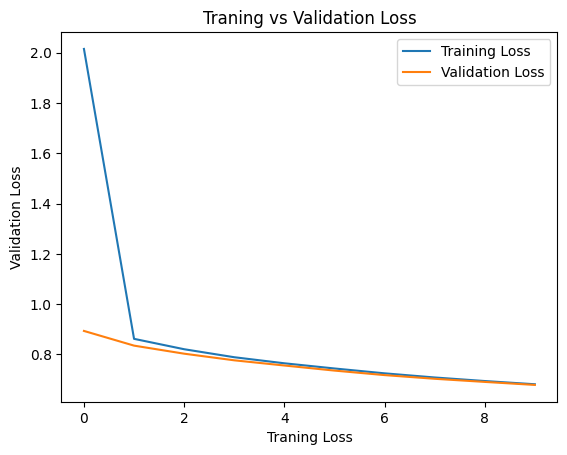

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Traning vs Validation Loss')
plt.xlabel('Traning Loss')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

# Eng-to-French Prediction Function

In [ ]:
def predict_french_sentence(english_sentence, english_tokenizer, french_tokenizer, model, max_french_length):

    english_sequence = english_tokenizer.texts_to_sequences([english_sentence])
    padded_english_sequence = pad_sequences(english_sequence, maxlen=max_french_length, padding='post')
    predicted_french_sequence = model.predict(padded_english_sequence)
    predicted_french_sentence = french_tokenizer.sequences_to_texts(np.argmax(predicted_french_sequence, axis=-1))
    return predicted_french_sentence[0]

In [ ]:
# Example1:
english_sentence = "How are you?"
predicted_french = predict_french_sentence(english_sentence, x_train_tok, y_train_tok, model, max_french_length)
print(f"English: {english_sentence}")
print(f"Predicted French: {predicted_french}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
English: How are you?
Predicted French: comment êtes tu


In [ ]:
import pickle

# Save the model
with open('Eng_to_French.pkl', 'wb') as f:
    pickle.dump(model, f)